## Supervised learning

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Part 1: Descriptive statistics and preprocessing

1) Charger les jeux de données _*train.csv*_ et _*test.csv*_, afficher leurs dimensions, afficher les premières lignes, et fournir un résumé statistique à l’aide de [pandas.DataFrame.describe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) pour chaque jeu de données.

In [3]:
# Answer

# Chargement respéctivement des données train.csv et test.csv dans les variables sous les noms train et test
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

In [4]:
# Affichage des dimensions des variables train et test
print("La dimension de train.csv est", train.shape)
print("La dimension de test.csv est", test.shape)

La dimension de train.csv est (1000, 38)
La dimension de test.csv est (460, 38)


In [5]:
# Affichage des 5 premières lignes dans le tableau de train
train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


In [6]:
# Affichage des 5 premières lignes dans le tableau de test
test.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1001,20,74.0,10206,3,3,1952,1952,0.0,0,...,0,0,0,0,0,0,0,7,2009,82000
1,1002,30,60.0,5400,5,6,1920,1950,0.0,0,...,0,20,94,0,0,0,0,1,2007,86000
2,1003,20,75.0,11957,8,5,2006,2006,53.0,24,...,144,104,0,0,0,0,0,7,2008,232000
3,1004,90,NaN,11500,5,6,1976,1976,164.0,0,...,0,0,0,0,0,0,0,6,2007,136905
4,1005,120,43.0,3182,7,5,2005,2006,16.0,16,...,156,0,0,0,0,0,0,5,2009,181000


In [7]:
# Création d'un résumé statistique à l'aide de pandas.DataFrame.describe pour le train
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1000.000000,1000.000000,827.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,994.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,56.880000,69.95526,10691.176000,6.125000,5.587000,1971.633000,1985.279000,109.225352,445.214000,...,97.353000,47.669000,21.413000,3.703000,15.055000,1.160000,45.384000,6.307000,2007.830000,182284.451000
std,288.819436,42.256375,23.20269,11412.668294,1.383217,1.108901,30.007945,20.412296,188.885856,442.394927,...,124.392314,67.988557,60.696528,30.915733,55.467744,26.103329,525.449337,2.691095,1.326974,80291.215207
min,1.000000,20.000000,21.00000,1300.000000,1.000000,1.000000,1880.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,250.750000,20.000000,60.00000,7585.250000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130000.000000
50%,500.500000,50.000000,70.00000,9451.000000,6.000000,5.000000,1974.000000,1994.000000,0.000000,384.500000,...,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163995.000000
75%,750.250000,70.000000,80.00000,11628.500000,7.000000,6.000000,2000.250000,2004.000000,174.750000,725.000000,...,171.250000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,1000.000000,190.000000,313.00000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,2260.000000,...,857.000000,523.000000,552.000000,508.000000,410.000000,648.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
# Création d'un résumé statistique à l'aide de pandas.DataFrame.describe pour le test
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,460.000000,460.000000,374.000000,460.000000,460.000000,460.000000,460.000000,460.000000,458.000000,460.000000,...,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000
mean,1230.500000,56.934783,70.259358,10137.810870,6.043478,5.550000,1970.473913,1983.967391,91.661572,440.217391,...,87.486957,44.467391,23.130435,2.771739,15.073913,6.234783,39.369565,6.354348,2007.784783,177957.597826
std,132.934821,42.442529,26.552888,5742.968834,1.382375,1.122022,30.640323,21.137918,162.355140,485.034721,...,127.246479,62.339231,62.078280,25.519399,56.442762,60.252277,425.963261,2.733334,1.331448,77569.003221
min,1001.000000,20.000000,21.000000,1477.000000,2.000000,3.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,52500.000000
25%,1115.750000,20.000000,58.250000,7500.000000,5.000000,5.000000,1950.000000,1965.750000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129000.000000
50%,1230.500000,50.000000,68.000000,9511.500000,6.000000,5.000000,1971.000000,1992.000000,0.000000,376.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,161750.000000
75%,1345.250000,70.000000,80.000000,11500.000000,7.000000,6.000000,2000.000000,2004.000000,145.000000,694.750000,...,161.250000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,206925.000000
max,1460.000000,190.000000,313.000000,63887.000000,10.000000,9.000000,2009.000000,2009.000000,1378.000000,5644.000000,...,736.000000,547.000000,330.000000,304.000000,480.000000,738.000000,8300.000000,12.000000,2010.000000,745000.000000


2) Extraire la variable cible ```SalePrice``` des jeux de données ```train``` et ```test```, et les stocker respectivement sous les noms ```train_target``` et ```test_target```. Supprimer les variables inutiles de ces mêmes jeux de données.

In [9]:
# Answer

# Extraire la variable cible SalePrice des jeux de données train et test, et les stocker respectivement sous les noms train_target et test_target
train_target = train["SalePrice"]
test_target = test["SalePrice"]

# Suppression des variables inutiles(Id et SalePrice) de données train et test 
train.drop("Id", axis = 1, inplace=True)
test.drop("Id", axis = 1, inplace=True)
train_features = train.drop("SalePrice", axis = 1)
test_features = test.drop("SalePrice", axis = 1)

In [10]:
# Affichage des 2 nouveaux données (train_target et test_target)

In [11]:
train_target

0      208500
1      181500
2      223500
3      140000
4      250000
        ...  
995    121600
996    136500
997    185000
998     91000
999    206000
Name: SalePrice, Length: 1000, dtype: int64

In [12]:
test_target

0       82000
1       86000
2      232000
3      136905
4      181000
        ...  
455    175000
456    210000
457    266500
458    142125
459    147500
Name: SalePrice, Length: 460, dtype: int64

In [13]:
# Affichage des 4 données réstrictées (train_features, test_features, train et test)

In [14]:
train_features

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,51.0,4712,4,7,1946,1950,0.0,384,0,...,305,0,57,0,0,63,0,0,8,2006
996,20,NaN,10659,5,6,1961,1961,0.0,915,0,...,368,0,319,0,0,0,0,0,1,2006
997,20,NaN,11717,6,6,1970,1970,571.0,0,0,...,615,371,0,0,0,0,0,0,2,2009
998,30,60.0,9786,3,4,1922,1950,0.0,0,0,...,210,0,100,48,0,0,0,0,5,2006


In [15]:
test_features

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,20,74.0,10206,3,3,1952,1952,0.0,0,0,...,528,0,0,0,0,0,0,0,7,2009
1,30,60.0,5400,5,6,1920,1950,0.0,0,0,...,216,0,20,94,0,0,0,0,1,2007
2,20,75.0,11957,8,5,2006,2006,53.0,24,0,...,824,144,104,0,0,0,0,0,7,2008
3,90,NaN,11500,5,6,1976,1976,164.0,0,0,...,528,0,0,0,0,0,0,0,6,2007
4,120,43.0,3182,7,5,2005,2006,16.0,16,0,...,457,156,0,0,0,0,0,0,5,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,460,0,40,0,0,0,0,0,8,2007
456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,500,349,0,0,0,0,0,0,2,2010
457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,252,0,60,0,0,0,0,2500,5,2010
458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,240,366,0,112,0,0,0,0,4,2010


In [16]:
train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,51.0,4712,4,7,1946,1950,0.0,384,0,...,0,57,0,0,63,0,0,8,2006,121600
996,20,NaN,10659,5,6,1961,1961,0.0,915,0,...,0,319,0,0,0,0,0,1,2006,136500
997,20,NaN,11717,6,6,1970,1970,571.0,0,0,...,371,0,0,0,0,0,0,2,2009,185000
998,30,60.0,9786,3,4,1922,1950,0.0,0,0,...,0,100,48,0,0,0,0,5,2006,91000


In [17]:
test

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,20,74.0,10206,3,3,1952,1952,0.0,0,0,...,0,0,0,0,0,0,0,7,2009,82000
1,30,60.0,5400,5,6,1920,1950,0.0,0,0,...,0,20,94,0,0,0,0,1,2007,86000
2,20,75.0,11957,8,5,2006,2006,53.0,24,0,...,144,104,0,0,0,0,0,7,2008,232000
3,90,NaN,11500,5,6,1976,1976,164.0,0,0,...,0,0,0,0,0,0,0,6,2007,136905
4,120,43.0,3182,7,5,2005,2006,16.0,16,0,...,156,0,0,0,0,0,0,5,2009,181000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500
458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,366,0,112,0,0,0,0,4,2010,142125


3) Définir une fonction qui identifie les variables contenant des valeurs manquantes, et qui retourne pour chacune : le nom de la variable, le nombre de valeurs manquantes, ainsi que le pourcentage de valeurs manquantes.

In [18]:
# Answer

# Fonction qui identifie les variables contenant des valeurs manquantes, et qui retourne pour chacune :
# le nom de la variable, le nombre de valeurs manquantes, ainsi que le pourcentage de valeurs manquantes
def Data_NaN(data):
    
    column_NaN = data.isna().sum()

    p = (column_NaN / len(data)) * 100

    resultat = pd.DataFrame({
        "nombre de valeurs manquantes": column_NaN,
        "pourcentage de valeurs manquantes": p.round(2)
    })
    
    return resultat[resultat["nombre de valeurs manquantes"] > 0]

In [19]:
# Application de la fonction Data_NaN sur le donnée train_features
res1 = Data_NaN(train_features)
res1

,nombre de valeurs manquantes,pourcentage de valeurs manquantes
LotFrontage,173,17.3
MasVnrArea,6,0.6
GarageYrBlt,56,5.6


In [20]:
# Application de la fonction Data_NaN sur le donnée test
res2 = Data_NaN(test_features)
res2

,nombre de valeurs manquantes,pourcentage de valeurs manquantes
LotFrontage,86,18.70
MasVnrArea,2,0.43
GarageYrBlt,25,5.43


In [21]:
# Verification si les cibles(train_target et test_target) ont des valeurs manquantes 
check1 = train_target.isna().sum()
print("Le nombre valeur manquant dans le train_target est", check1)
check2 = test_target.isna().sum()
print("Le nombre valeur manquant dans le test_target est", check2)

Le nombre valeur manquant dans le train_target est 0
Le nombre valeur manquant dans le test_target est 0


4) Pour simplifier, remplir les valeurs manquantes avec 0 en utilisant [pandas.DataFrame.fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) (modifier directement le jeu de données concerné).

In [22]:
# Answer

# Completion des valeurs manquantes avec 0 pour ces qui sont concernées
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

train_features.fillna(0, inplace=True)
test_features.fillna(0, inplace=True)

In [23]:
# Affichage de tous les données après le completion des valeurs manquantes avec 0

In [24]:
train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,51.0,4712,4,7,1946,1950,0.0,384,0,...,0,57,0,0,63,0,0,8,2006,121600
996,20,0.0,10659,5,6,1961,1961,0.0,915,0,...,0,319,0,0,0,0,0,1,2006,136500
997,20,0.0,11717,6,6,1970,1970,571.0,0,0,...,371,0,0,0,0,0,0,2,2009,185000
998,30,60.0,9786,3,4,1922,1950,0.0,0,0,...,0,100,48,0,0,0,0,5,2006,91000


In [25]:
test

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,20,74.0,10206,3,3,1952,1952,0.0,0,0,...,0,0,0,0,0,0,0,7,2009,82000
1,30,60.0,5400,5,6,1920,1950,0.0,0,0,...,0,20,94,0,0,0,0,1,2007,86000
2,20,75.0,11957,8,5,2006,2006,53.0,24,0,...,144,104,0,0,0,0,0,7,2008,232000
3,90,0.0,11500,5,6,1976,1976,164.0,0,0,...,0,0,0,0,0,0,0,6,2007,136905
4,120,43.0,3182,7,5,2005,2006,16.0,16,0,...,156,0,0,0,0,0,0,5,2009,181000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500
458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,366,0,112,0,0,0,0,4,2010,142125


In [26]:
train_features

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,51.0,4712,4,7,1946,1950,0.0,384,0,...,305,0,57,0,0,63,0,0,8,2006
996,20,0.0,10659,5,6,1961,1961,0.0,915,0,...,368,0,319,0,0,0,0,0,1,2006
997,20,0.0,11717,6,6,1970,1970,571.0,0,0,...,615,371,0,0,0,0,0,0,2,2009
998,30,60.0,9786,3,4,1922,1950,0.0,0,0,...,210,0,100,48,0,0,0,0,5,2006


In [27]:
test_features

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,20,74.0,10206,3,3,1952,1952,0.0,0,0,...,528,0,0,0,0,0,0,0,7,2009
1,30,60.0,5400,5,6,1920,1950,0.0,0,0,...,216,0,20,94,0,0,0,0,1,2007
2,20,75.0,11957,8,5,2006,2006,53.0,24,0,...,824,144,104,0,0,0,0,0,7,2008
3,90,0.0,11500,5,6,1976,1976,164.0,0,0,...,528,0,0,0,0,0,0,0,6,2007
4,120,43.0,3182,7,5,2005,2006,16.0,16,0,...,457,156,0,0,0,0,0,0,5,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,460,0,40,0,0,0,0,0,8,2007
456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,500,349,0,0,0,0,0,0,2,2010
457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,252,0,60,0,0,0,0,2500,5,2010
458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,240,366,0,112,0,0,0,0,4,2010


5) Décrire la variable cible ```train_target```

In [28]:
# Answer

# Déscriptionpour le donnée train_target
train_target.describe()
# or   train["SalePrice"].describe()

count      1000.000000
mean     182284.451000
std       80291.215207
min       34900.000000
25%      130000.000000
50%      163995.000000
75%      215000.000000
max      755000.000000
Name: SalePrice, dtype: float64

6) Tracer l’histogramme et la densité de ```train_target``` (vous pouvez utiliser le module [seaborn.displot](https://seaborn.pydata.org/generated/seaborn.displot.html))

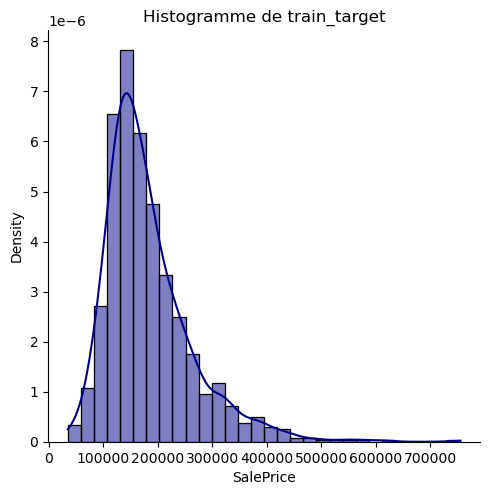

In [29]:
# Answer

# Tracage de l’histogramme et la densité de train_target
sns.displot(train_target, bins=30, kde=True, stat="density", color="darkblue")
plt.title("Histogramme de train_target")
plt.show()

$Interprétation:$ Cet histogramme, dont la queue est plus longue ou plus épaisse du coté droit, nous dit tout d'abord que 50% de nos maisons sont mises en vente à des prix inférieurs à 180 000.On a ce resultat car la médiane est tiré vers la gauche de la moyenne. Et on distingue tout particulièrement  le nombre record (juste un peu au dessus de 186 maisons) de maisons qui se vendent  autour de 150 000

7) Tracer les histogrammes de toutes les autres variables en utilisant [pandas.DataFrame.hist](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html)

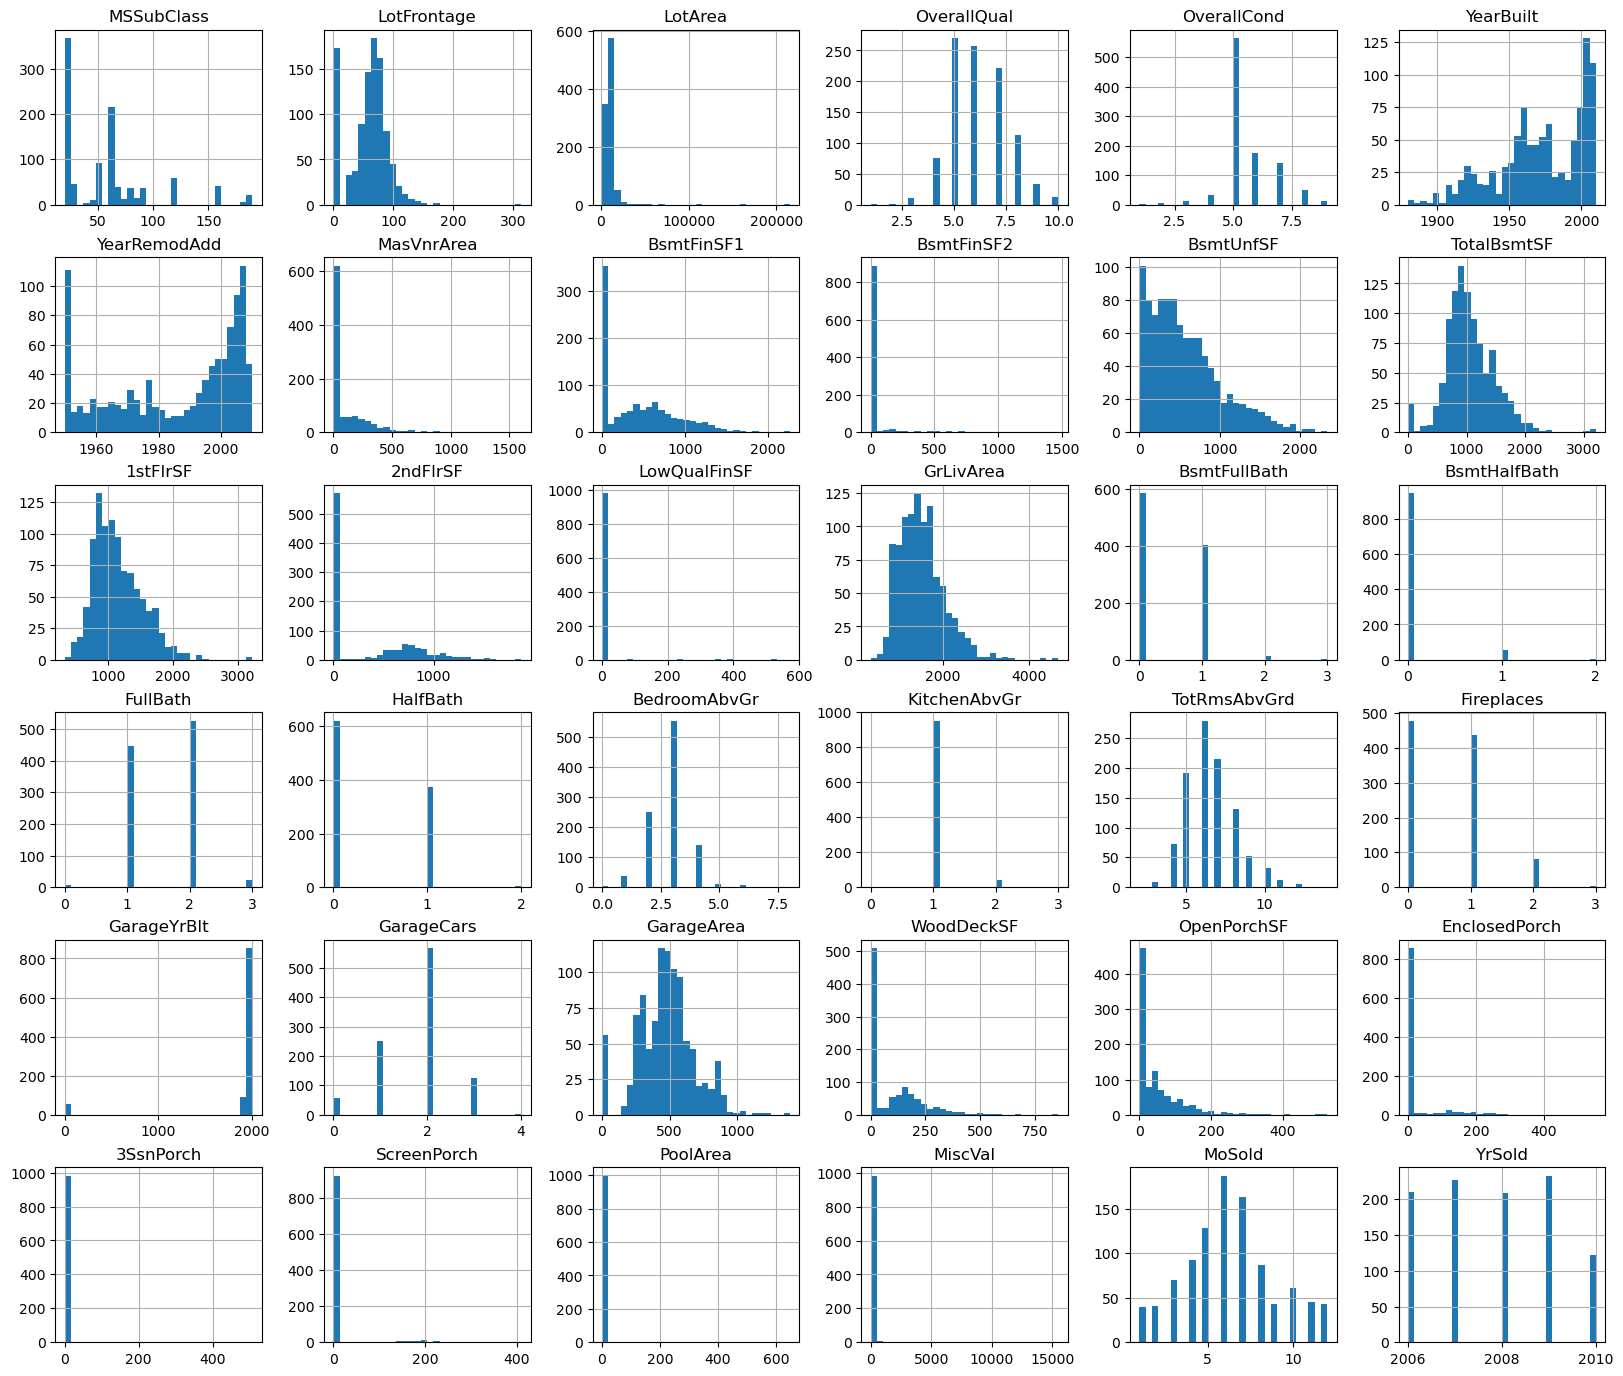

In [30]:
# Answer

# Tracage des histogrammes de toutes les autres variables 
train_features.hist(figsize=(20,20), bins=30, layout=(7, 6));

8) Calculer et tracer la matrice de corrélation entre les variables à l’aide de [seaborn.heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html). Commenter les résultats.

In [31]:
# Answer

# Calcul la matrice de corrélation entre les variables
train.corr()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.214691,-0.115279,0.041102,-0.057754,0.029721,0.043926,0.016507,-0.062344,-0.034473,...,-0.024661,0.012560,-0.017735,-0.040800,-0.015886,-0.013268,-0.019086,0.026961,-0.033033,-0.081252
LotFrontage,-0.214691,1.000000,0.081224,0.187252,-0.050950,0.033475,0.083385,0.125067,0.014593,-0.004355,...,-0.021759,0.050979,0.045823,0.041171,0.017917,0.082153,-0.066476,0.018110,0.008512,0.237649
LotArea,-0.115279,0.081224,1.000000,0.099715,0.003108,0.004951,0.012234,0.079471,0.194581,0.120933,...,0.182296,0.061517,-0.010237,0.012324,0.043920,0.024137,0.031380,0.006856,-0.015487,0.265493
OverallQual,0.041102,0.187252,0.099715,1.000000,-0.094873,0.568318,0.562643,0.417213,0.209785,-0.046796,...,0.239211,0.314292,-0.105513,0.016857,0.092738,0.024369,-0.033367,0.087834,-0.022223,0.797666
OverallCond,-0.057754,-0.050950,0.003108,-0.094873,1.000000,-0.408921,0.071696,-0.147077,-0.044847,0.045831,...,0.021675,-0.024665,0.055631,0.005032,0.062814,-0.018844,0.084780,-0.025899,0.041353,-0.095816
YearBuilt,0.029721,0.033475,0.004951,0.568318,-0.408921,1.000000,0.571433,0.322618,0.238930,-0.035047,...,0.228536,0.177204,-0.373832,0.029894,-0.035542,-0.033132,-0.040592,0.029076,0.011277,0.527193
YearRemodAdd,0.043926,0.083385,0.012234,0.562643,0.071696,0.571433,1.000000,0.182999,0.124104,-0.071096,...,0.221438,0.249971,-0.196071,0.019946,-0.014484,0.021244,-0.002730,0.040424,0.050460,0.526195
MasVnrArea,0.016507,0.125067,0.079471,0.417213,-0.147077,0.322618,0.182999,1.000000,0.245608,-0.067279,...,0.177446,0.096313,-0.085952,0.009388,0.070636,-0.012570,-0.029455,-0.012317,0.006298,0.491609
BsmtFinSF1,-0.062344,0.014593,0.194581,0.209785,-0.044847,0.238930,0.124104,0.245608,1.000000,-0.041570,...,0.213987,0.059104,-0.093862,-0.000189,0.064223,0.038453,0.001039,-0.021138,0.012639,0.389868
BsmtFinSF2,-0.034473,-0.004355,0.120933,-0.046796,0.045831,-0.035047,-0.071096,-0.067279,-0.041570,1.000000,...,0.079912,0.011523,0.020054,-0.033947,0.106524,0.065338,-0.015501,-0.000524,0.036306,0.000359


<Axes: >

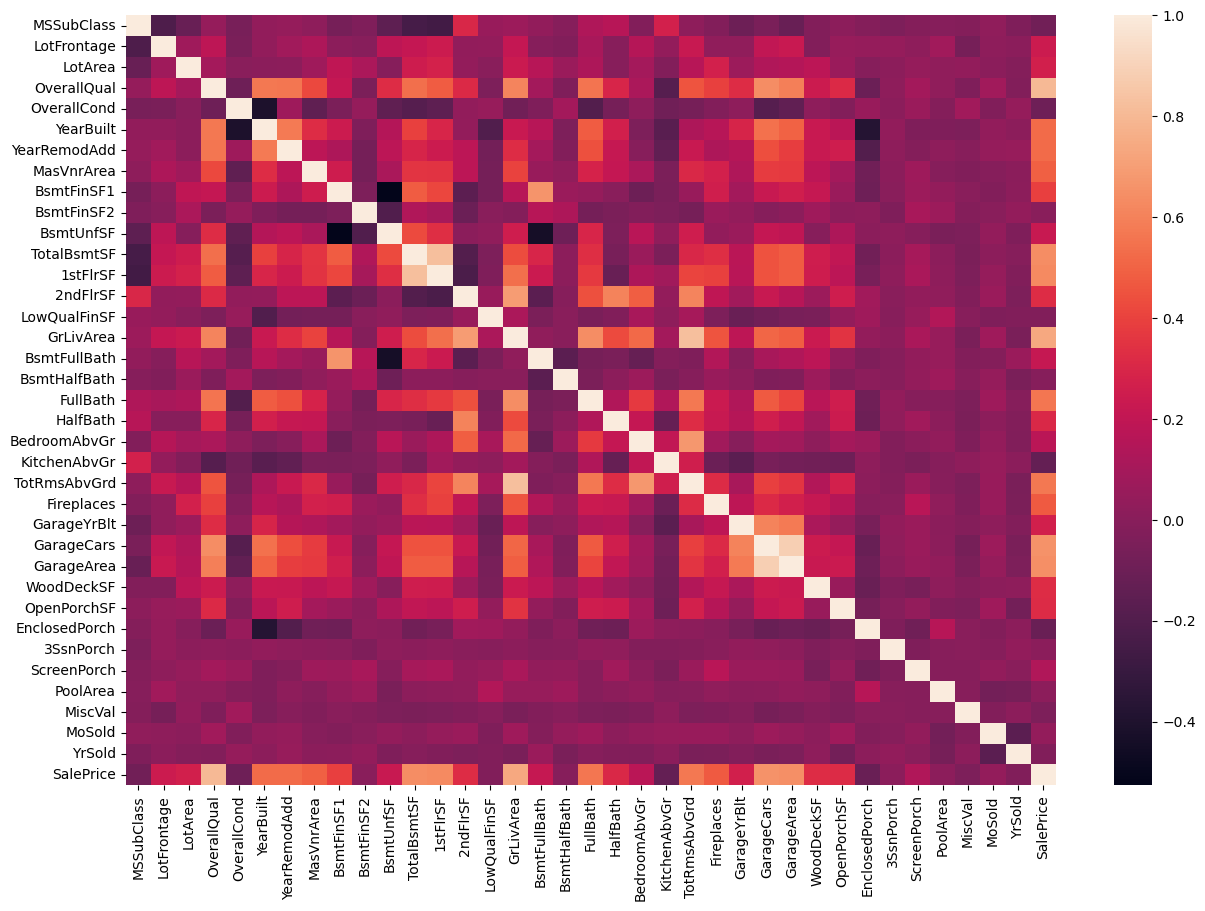

In [32]:
# Tracage de la matrice de corrélation entre les variables
correlation_matrix = train.corr()
plt.figure(figsize = (15,10))
sns.heatmap(correlation_matrix)

<Axes: >

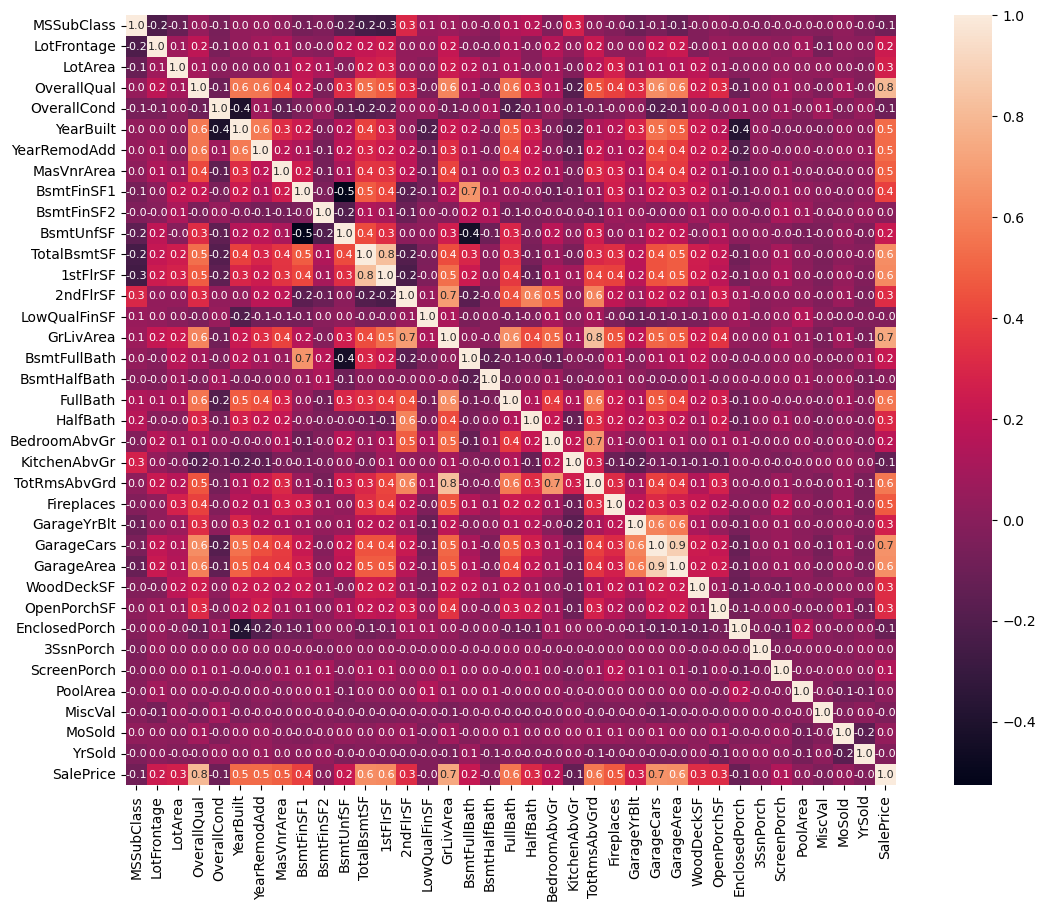

In [33]:
plt.figure(figsize = (15,10))
sns.heatmap(correlation_matrix, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8})

$Interprétation:$ Cette matrice de couleur nous renseigne à quel point deux variables quelconque de notre jeu de données s'influencent l'une sur l'autre. La couleur qui tend à se blanchir sur la diagonale nous sert de repère quant à une corrélation parfaite. Tandis que la coloration passe du rouge jusqu'au violet au fur et à mesure que les variables n'ont rien à voir. Basculer du violet vers noir indique cependant une autre forme de corrélation: La diminution de l'un des variables entraîne l'augmentation de l'autre. \
Exemple 1: Autour de la diagonale, un peu plus bas, on voit ce carré clair qui nous montre surtout que l'aire du garage en pieds-carré (ou GarageArea ) influence fortement la capacité du garage en nombre de voiture (ou GarageCars). On pourrait s'y attendre. \
En effet, avec une aire plus grande on a une plus grande capacité (corrélation fortement positive)\
Exemple 2: A contrario, Un peu plus haut sur la figure, toujours autour de la diagonale, on voit ces deux carrés noirs qui en sandwich ce carré clair. Ces couleurs noirs à cet endroits traduient le fait que BsmtFinSF1 et BsmtUnfSF ont tendance à évoluer dans le sens contraire. Autrement dit, la taille de surface Type1 aménagée diminue quand la taille de surface non fini en sous-sol (BsmtUnfSF) augmente.

9) Visualiser les corrélations entre ```SalePrice``` et les autres variables en utilisant un [seaborn.barplot](https://seaborn.pydata.org/generated/seaborn.barplot.html).

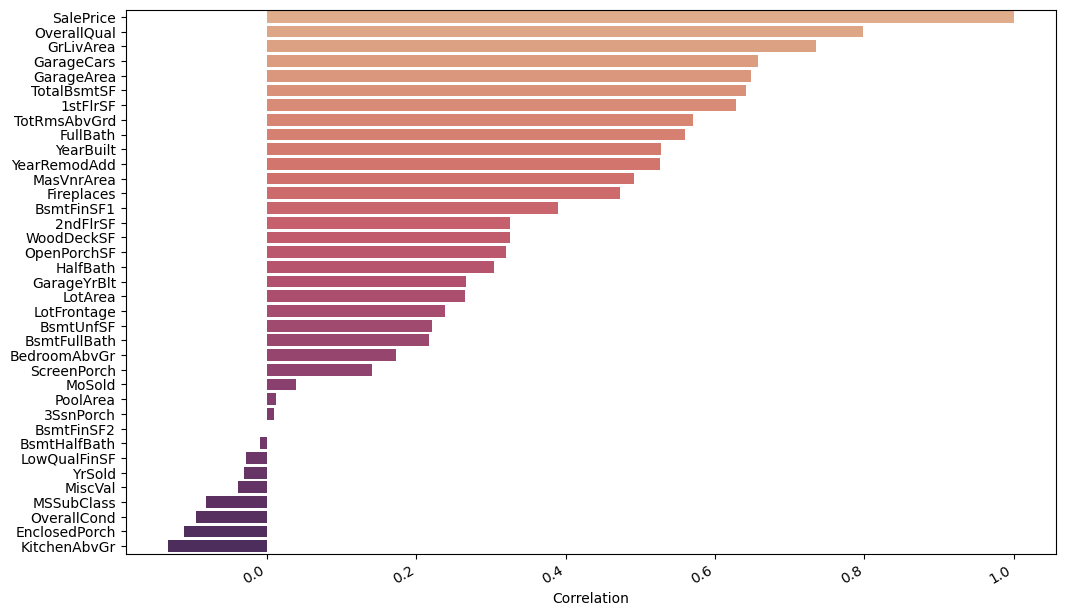

In [34]:
# Answer

# Visualisation les corrélations entre SalePrice et les autres variables 
correlation_matrix_sp = train.corr()
saleprice_correlation = correlation_matrix_sp.loc["SalePrice", :]
saleprice_correlation = saleprice_correlation.sort_values(ascending=False)
fig = plt.figure(figsize=(12, 8))
sns.barplot(saleprice_correlation, orient='h', palette='flare')
plt.xlabel("Correlation")
fig.autofmt_xdate()

$Commentaire:$Cette figure montre, à travers ces jeux de couleurs, à quel point chacune de nos variables interviennent dans le prix de la propiété qu'on considère.
Servant de référence, la plus longue barre au couleur très claire que l'on voit tout en haut donne tout simplement la corrélation entre SalePrice et SalePrice (qui,comme on le voit, est parfaite). Maintenant, si on descend un peu, on voit rapidement que la première autre variable qui fortement influence le prix, c'est OverallQual. Ce qui nous conforte dans l'idée que rien fait plus envolé le prix d'une maison que la qualité des matériaux utilisés pour sa construction.

10) Visualiser le nuage de points de la variable ```SalePrice``` en fonction de ```GrLivArea```. Commenter.

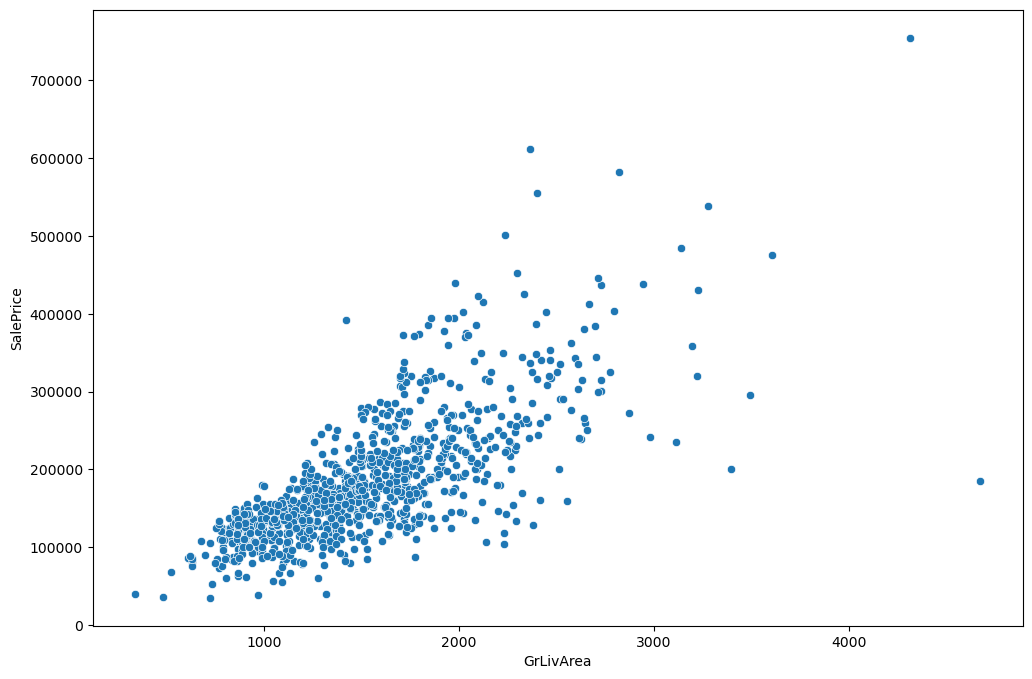

In [35]:
# Answer

plt.figure(figsize =(12, 8))
sns.scatterplot(data = train, x = "GrLivArea", y = "SalePrice");

$Commentaire:$ Au vue de ce diagramme, on remarque que  
1. La plupart des maisons que nous considérons ont une surface habitable au dessus du.. (ou GrLivArea) qui se situe entre 500 et 2500.
2. Puis que ces maisons là sont mises en vente gobalement entre 80 000 et 300 000. On a donc une corrélation positive entre ces deux variables.
3. Troisièmement, On voit que le prix de vente tend à augmenter quand le GrLivArea augmente. Bien qu'il ny a pas beaucoup de maison au dessus d'un GrLivArea de 3000.On pourra noter aussi ces deux valeurs trop exceptionnels d'un GrLivArea plus  de 4000 qui peuvent etre mise de coté car ils risquent de parasiter nos résultats.

11) Visualiser le boxplot de la variable ```SalePrice``` en fonction de ```OverallQual``` en utilisant [seaborn.boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html). Interpréter le boxplot.

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

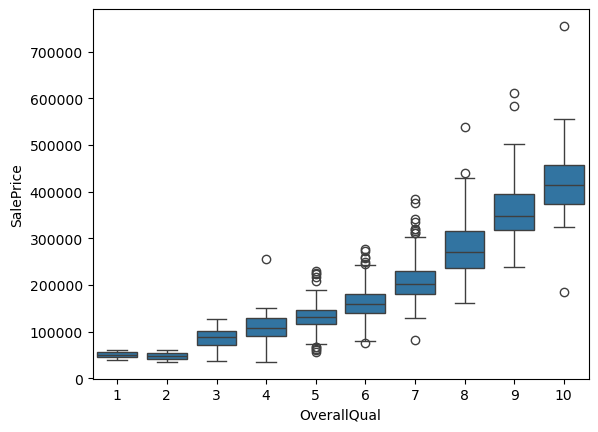

In [36]:
# Answer

sns.boxplot(data = train, x="OverallQual", y="SalePrice")

$Interpretation:$ Que nous dit ce diagramme de petites boites? En voyant cette figure, on observe que la taille des petites boites tend à s'agrandir quand on va de gauche vers la droite. On voit aussi, avec cela,une montée qui se confirme du coté des prix. Tout ceci nous force à conclure que si on monte en qualité on rend plus chère encore, et à chaque fois, pas moins de 50% de nos propriété(ou maisons) 

Bien que ces maisons se renchérit (sont de plus en plus chères)avec la qualité, on remarque toutefois qu'on a un éventail qui s'ouvre au niveau des prix. On voit cela notamment avec ces boites qui s'étire de haut en bas. En effet l'augmentation de l'interquartile traduit plus de dispersion autour de la ligne médiane. 

Maintenant, on peut toujours prendre un cas et expliquer encore ce qui s'y passe. 
Exemple: Pour les maisons à matériaux de qualité 7, on remarque que les moins chères sont autour de 140 000, que 25% de ces maisons sont proposés entre 140 000 et 180 000, que 50% ont des prix inférieurs à 230 000 et que les plus chères se vendent autour de 305 000(Sauf quelques-unes consédérées négligeables). 

Au final, ce diagramme nous permet de nous rendre compte du "poids"  que représente la qualité des matériaux de constructions dans le calcul des prix de vente.

12) Visualiser les distributions empiriques des jeux de données d’entraînement et de test (pour certaines variables). Commenter les résultats.

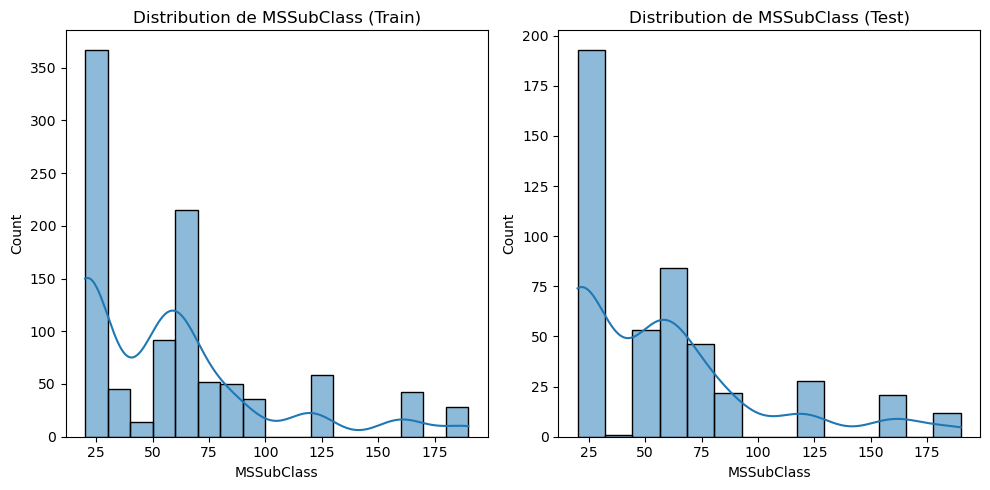

Commentaires pour la variable 'MSSubClass' :
  Moyenne approximative: (Train): 56.88 | (Test): 56.93
  Étendue approximative: (Train): 170.00 | (Test): 170.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




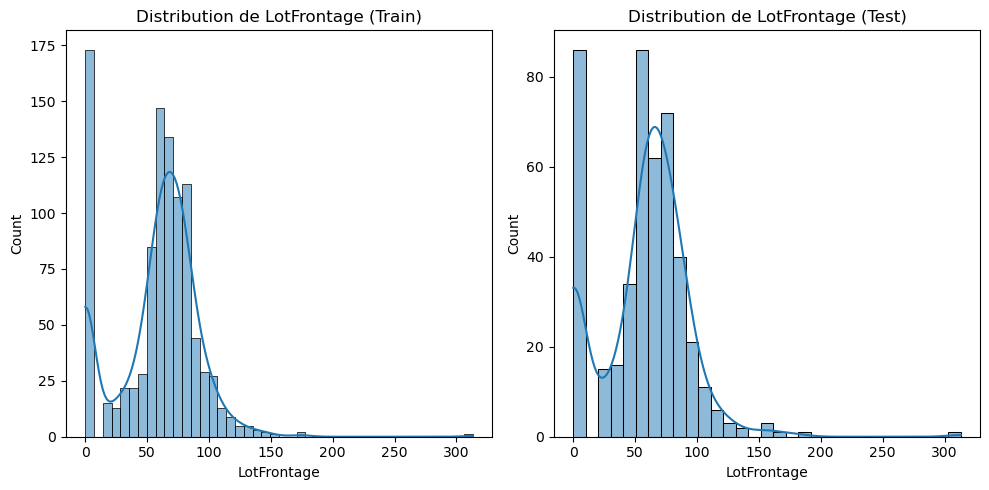

Commentaires pour la variable 'LotFrontage' :
  Moyenne approximative: (Train): 57.85 | (Test): 57.12
  Étendue approximative: (Train): 313.00 | (Test): 313.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




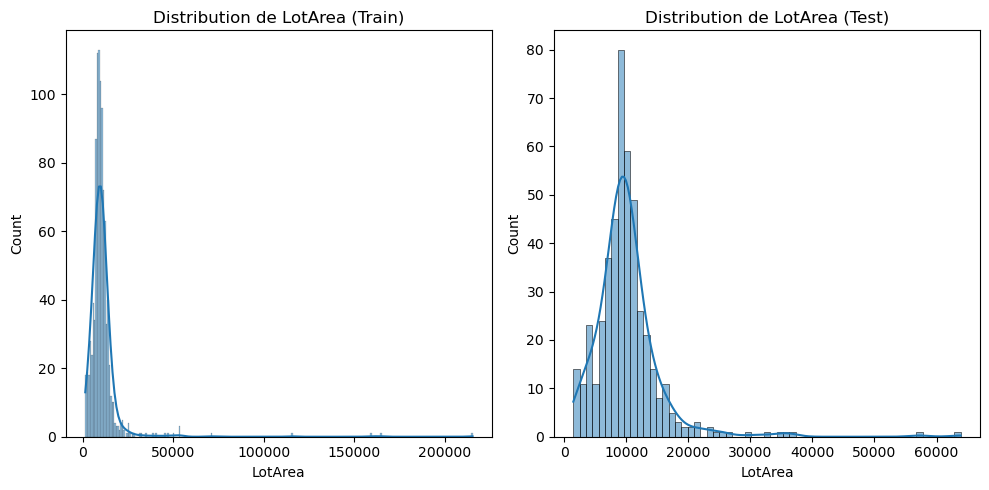

Commentaires pour la variable 'LotArea' :
  Moyenne approximative: (Train): 10691.18 | (Test): 10137.81
  Étendue approximative: (Train): 213945.00 | (Test): 62410.00
La différence peut suggérer une différence significative 




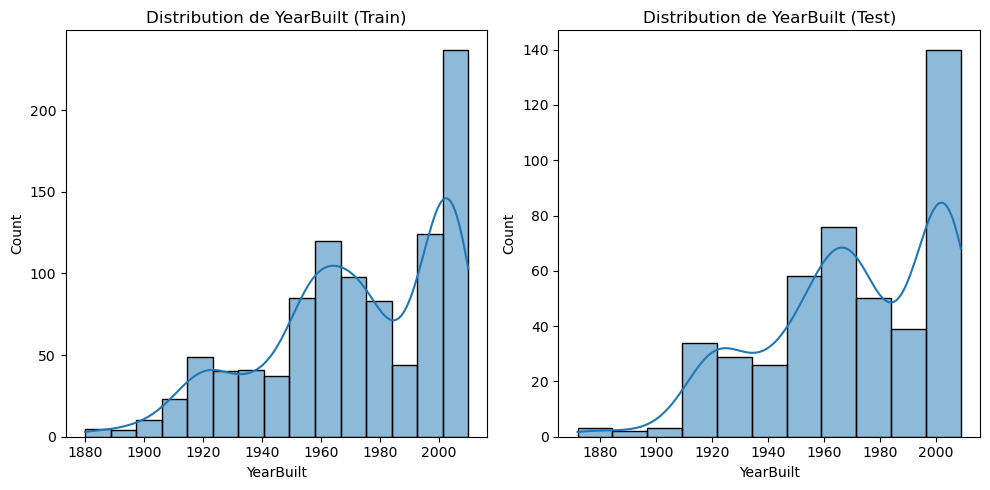

Commentaires pour la variable 'YearBuilt' :
  Moyenne approximative: (Train): 1971.63 | (Test): 1970.47
  Étendue approximative: (Train): 130.00 | (Test): 137.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




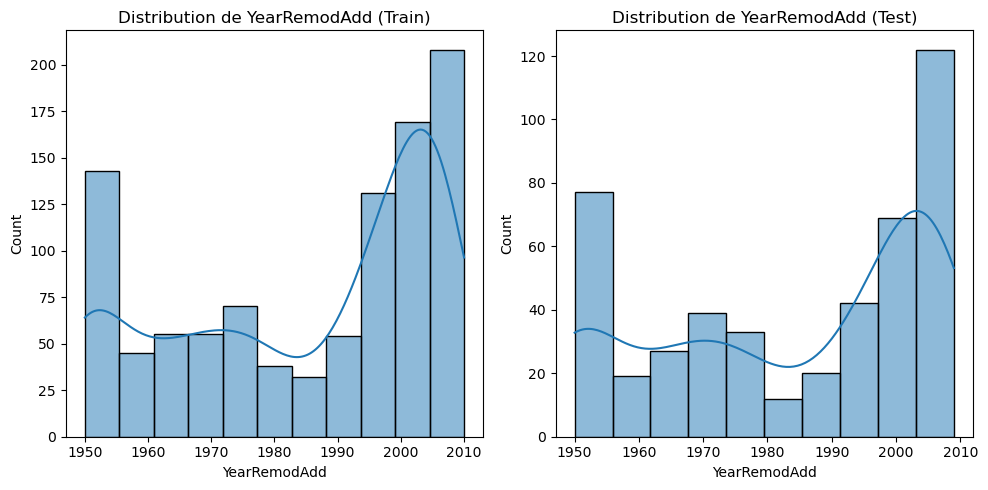

Commentaires pour la variable 'YearRemodAdd' :
  Moyenne approximative: (Train): 1985.28 | (Test): 1983.97
  Étendue approximative: (Train): 60.00 | (Test): 59.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




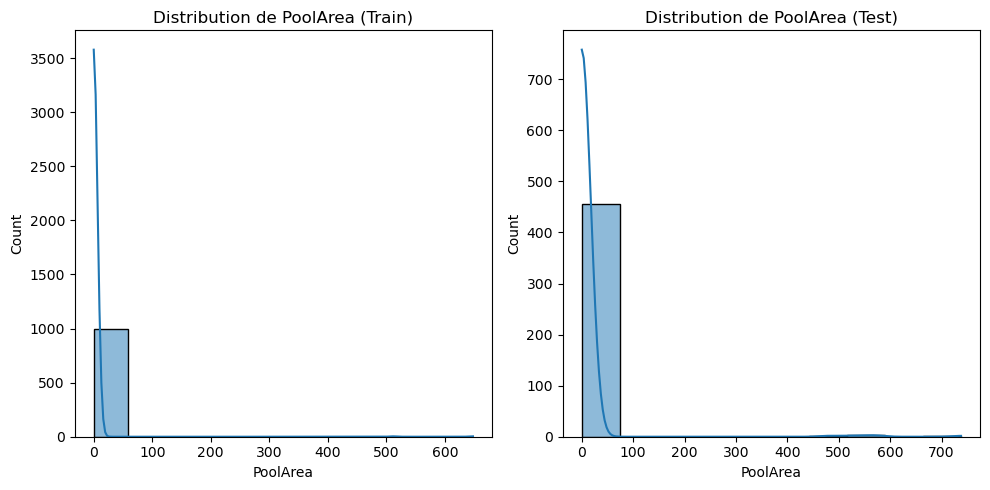

Commentaires pour la variable 'PoolArea' :
  Moyenne approximative: (Train): 1.16 | (Test): 6.23
  Étendue approximative: (Train): 648.00 | (Test): 738.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




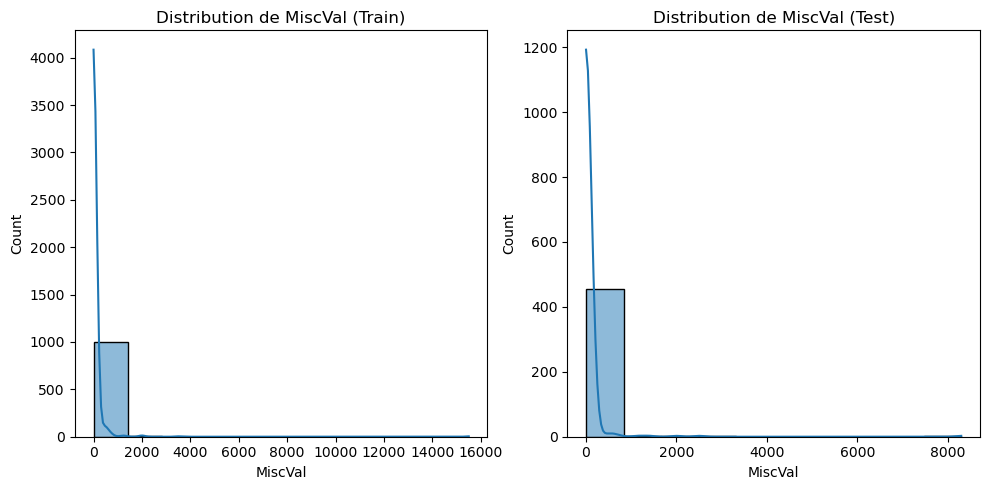

Commentaires pour la variable 'MiscVal' :
  Moyenne approximative: (Train): 45.38 | (Test): 39.37
  Étendue approximative: (Train): 15500.00 | (Test): 8300.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




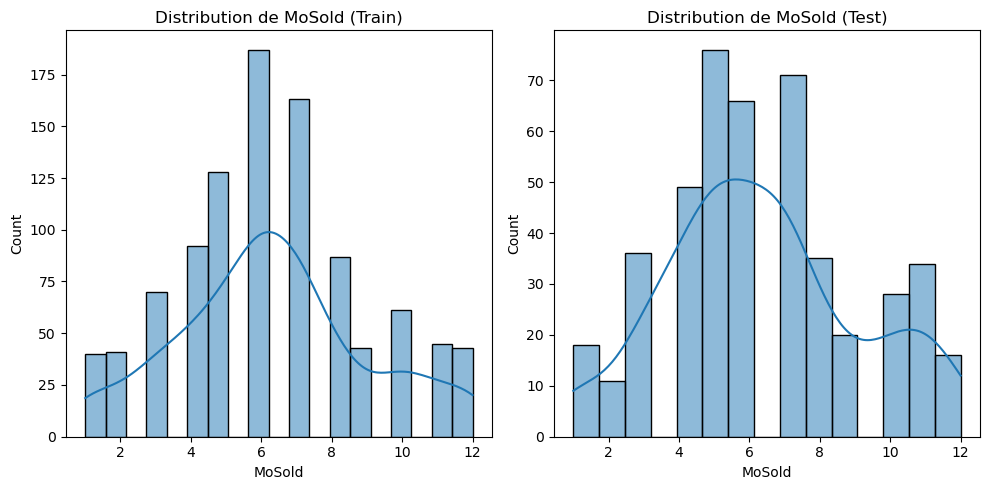

Commentaires pour la variable 'MoSold' :
  Moyenne approximative: (Train): 6.31 | (Test): 6.35
  Étendue approximative: (Train): 11.00 | (Test): 11.00
La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.




In [37]:
# Answer

# Liste des variables à visualiser
variables_to_visualize = ["MSSubClass", "LotFrontage", "LotArea", "YearBuilt", "YearRemodAdd", "PoolArea", "MiscVal", "MoSold"]

# Visualisation des distributions pour chaque variable
for var in variables_to_visualize:
    plt.figure(figsize=(10, 5))

    # Distribution dans le jeu de données d'entraînement
    plt.subplot(1, 2, 1)
    sns.histplot(train_features[var], kde=True)
    plt.title(f'Distribution de {var} (Train)')

    # Distribution dans le jeu de données de test
    plt.subplot(1, 2, 2)
    sns.histplot(test_features[var], kde=True)
    plt.title(f'Distribution de {var} (Test)')

    plt.tight_layout()
    plt.show()

    # Commentaires sur les résultats pour chaque variable
    print(f"Commentaires pour la variable '{var}' :")

    # Comparaison des tendances centrales (moyenne/médiane - approximée visuellement)
    mean_train = train_features[var].mean()
    mean_test = test_features[var].mean()
    print(f"  Moyenne approximative: (Train): {mean_train:.2f} | (Test): {mean_test:.2f}")

    # Comparaison de la dispersion (étendue/variabilité - approximée visuellement)
    range_train = train_features[var].max() - train_features[var].min()
    range_test = test_features[var].max() - test_features[var].min()
    print(f"  Étendue approximative: (Train): {range_train:.2f} | (Test): {range_test:.2f}")

    # Commentaires sur la forme et les différences potentielles
    # (Ceci est une interprétation qualitative basée sur les histogrammes et KDE)
    if 0 <= abs(mean_train - mean_test) <= 10:
        print("La différence est une faible différence indiquant que la plage de valeurs observées pour la caractéristique est similaire dans les deux ensembles.")
    else:
        print("La différence peut suggérer une différence significative ")
    
    print("\n")

### Part 2: Entrainnement et evaluation du modeles

13) Divisez les données en un ensemble d'entraînement et un ensemble de validation à l'aide de la fonction [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [38]:
# Importation de la fonction train_test_split
from sklearn.model_selection import train_test_split

# Diviser les données train pour le donée d'entrenaiment et le donné de validation
X_train, X_val, y_train, y_val = train_test_split(train_features, train_target, test_size=0.2)

In [39]:
## Affichage des 4 données qu'on obtient

In [40]:
X_train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
952,85,60.0,7200,5,8,1972,2003,0.0,660,0,...,396,192,0,0,0,0,0,0,4,2009
574,80,70.0,10500,5,7,1971,2005,82.0,349,0,...,288,35,0,0,0,0,0,0,12,2007
729,30,52.0,6240,4,5,1925,1950,0.0,152,0,...,539,0,23,112,0,0,0,0,1,2009
101,60,77.0,9206,6,5,1985,1985,336.0,0,0,...,476,192,46,0,0,0,0,0,6,2010
378,20,88.0,11394,9,2,2010,2010,350.0,1445,0,...,834,113,0,0,0,0,0,0,6,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,60,75.0,11404,7,5,1998,1999,202.0,252,0,...,541,192,84,0,0,0,0,0,7,2008
370,60,0.0,8121,6,5,2000,2000,0.0,0,0,...,460,100,40,0,0,0,0,0,1,2006
191,60,0.0,7472,7,9,1972,2004,138.0,626,0,...,484,0,32,0,0,0,0,0,6,2007
472,180,35.0,3675,6,5,2005,2005,80.0,459,0,...,525,0,28,0,0,0,0,0,6,2008


In [41]:
X_val

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
294,20,80.0,9600,6,5,1953,1953,238.0,1285,0,...,418,110,0,0,0,0,0,0,10,2009
905,20,80.0,9920,5,5,1954,1954,110.0,354,290,...,280,0,0,164,0,0,0,0,2,2010
984,90,75.0,10125,5,5,1977,1977,0.0,0,0,...,539,0,0,0,0,0,0,0,8,2009
124,20,48.0,17043,6,5,1979,1998,0.0,0,0,...,435,192,0,0,0,0,0,0,1,2009
89,20,60.0,8070,4,5,1994,1995,0.0,588,0,...,0,0,0,0,0,0,0,0,8,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,20,65.0,8450,7,5,2000,2001,108.0,0,0,...,539,120,55,0,0,0,0,0,12,2007
625,20,87.0,10000,6,6,1962,1962,261.0,0,0,...,440,0,0,0,0,385,0,0,2,2010
164,40,40.0,5400,6,7,1926,2004,0.0,370,0,...,216,0,0,183,0,0,0,0,10,2007
649,180,21.0,1936,4,6,1970,1970,0.0,131,499,...,0,0,0,0,0,0,0,0,12,2007


In [42]:
y_train

952    133900
574    139000
729    103000
101    178000
378    394432
        ...  
732    222500
370    172400
191    184000
472    148000
731    187500
Name: SalePrice, Length: 800, dtype: int64

In [43]:
y_val

294    167000
905    128000
984    126000
124    181000
89     123600
        ...  
742    179000
625    160000
164    152000
649     84500
571    120000
Name: SalePrice, Length: 200, dtype: int64

14) Entraînez un modèle de [régression linéaire](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) (nous choisissons la régression linéaire pour apprendre à prédire la variable cible) et évaluez ses performances en utilisant la [RMSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) (RMSE = Root Mean Square Error, ou racine de l’erreur quadratique moyenne) et le [MAPE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html) (MAPE = Mean Absolute Percentage Error, ou erreur absolue moyenne en pourcentage) comme métriques. Évaluez ses performances sur les données de test. Commentez les résultats.

**Rappel :**

$$RMSE(Y,\hat{Y}) = \sqrt{\frac{1}{n} \sum_{i=1}^n (Y_i - \hat{Y_i})^2}\quad\quad\quad MAPE(Y,\hat{Y}) = \frac{1}{n} \sum_{i=1}^n \frac{|Y_i - \hat{Y_i}|}{Y_i}$$

où $Y$ est la vraie valeur de la cible, et $\hat{Y}$ est la valeur prédite.

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [45]:
# Création de la fonction MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [46]:
# 1. Initialiser le modèle de régression linéaire
model = LinearRegression()

# 2. Entraîner le modèle sur l'ensemble d'entraînement
model.fit(X_train, y_train)

LinearRegression()

In [47]:
# Faire des prédictions sur l'ensemble de validation
y_pred_val = model.predict(X_val)

print("\nPrédictions sur l'ensemble de validation :")
y_pred_val


Prédictions sur l'ensemble de validation :


array([206348.20812945, 115815.47990152, 110705.93298084, 191078.4133584 ,
       122455.27525163, 233396.67372874, 229170.3943935 , 153210.27319939,
        67265.93887264,  75365.62935953, 330355.1084289 , 175612.37624651,
        95283.53191239, 116228.41562788, 220320.40488917,  65418.63229034,
       134897.67278875, 189943.0931258 , 240644.23597811, 210610.49992273,
       264401.18439462, 300264.5821113 , 293655.43733448, 186961.87859569,
       181072.48173036, 188682.83671711, 223880.57309792, 234946.24468305,
       266194.12443949, 240242.88167828, 234292.24264086, 118580.05058152,
       101224.03962839, 269851.5401759 , 167980.2783359 , 124571.96879099,
       126463.91518682, 199086.66913705, 262822.84610481, 167879.32996303,
        87987.73904965,  93764.38130538, 259841.82268742, 104836.28701812,
       294586.07587158, 233232.38279337, 200858.52245446, 161733.97737252,
       105468.97302032, 201585.47149458, 175643.37557991, 110389.57412141,
       204071.15762986, 1


Évaluation du modèle sur l'ensemble de validation :
Root Mean Squared Error (MSE): 43418.14
Mean Absolute Percentage Error (MAPE): 14.01


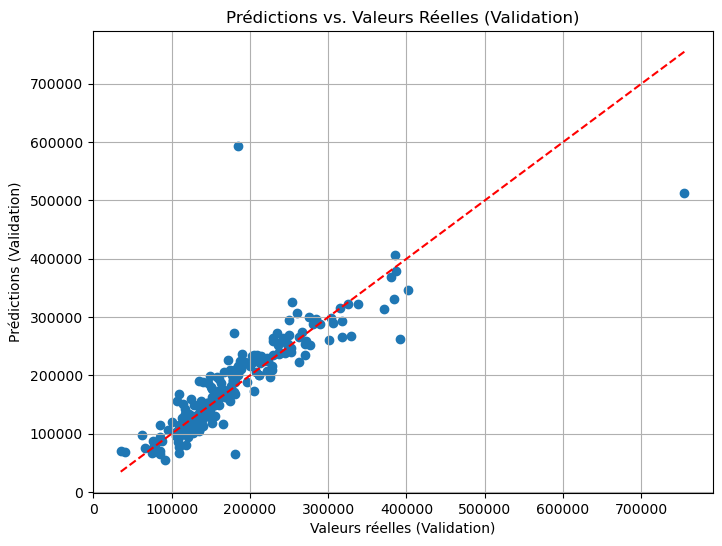

In [48]:
# Évaluer la performance du modèle
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mape_ = mape(y_val, y_pred_val)

print("\nÉvaluation du modèle sur l'ensemble de validation :")
print(f"Root Mean Squared Error (MSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_:.2f}")

# Visualisation des prédictions par rapport aux valeurs réelles
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_val)
plt.xlabel("Valeurs réelles (Validation)")
plt.ylabel("Prédictions (Validation)")
plt.title("Prédictions vs. Valeurs Réelles (Validation)")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--') # Ligne de référence
plt.grid(True)
plt.show()

Commentaire:




**Objectif : Améliorer les prédictions !**

15) Entraînez les modèles suivants et évaluez leurs performances sur les ensembles de validation et de test :
- [Régression par plus proches voisins (KNeighborsRegressor)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)
- [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- [Forêt aléatoire (Random Forest Regressor)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)


In [51]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


 Entraînement et évaluation de KNeighborsRegressor:
Modèle entraîné !
Performance sur la validation : RMSE = 44456.33, MAPE = 19.38
Performance sur le test : RMSE = 45676.78, MAPE = 19.06


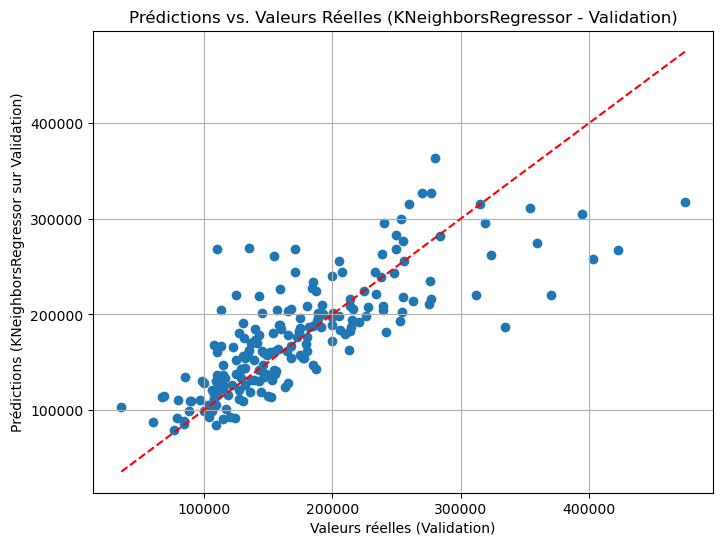


 Entraînement et évaluation de Ridge:
Modèle entraîné !
Performance sur la validation : RMSE = 28299.78, MAPE = 14.12
Performance sur le test : RMSE = 44013.88, MAPE = 14.81


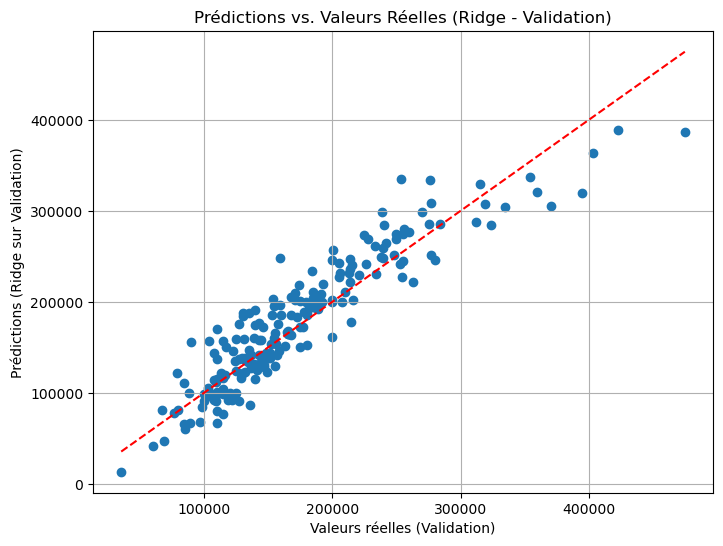


 Entraînement et évaluation de Random Forest Regressor:
Modèle entraîné !
Performance sur la validation : RMSE = 27080.18, MAPE = 11.71
Performance sur le test : RMSE = 36354.09, MAPE = 12.06


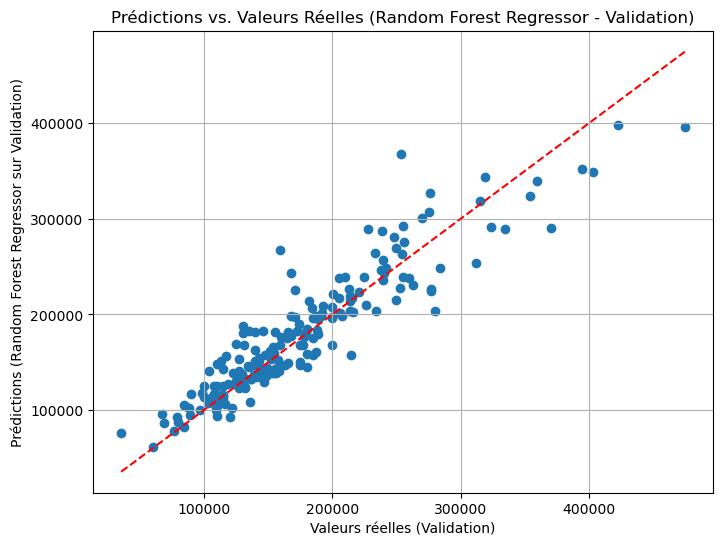

,Modèle,RMSE (Validation),MAPE (Validation),RMSE (Test),MAPE (Test)
0,KNeighborsRegressor,44456.326241,19.380415,45676.777961,19.059725
1,Ridge,28299.775509,14.120136,44013.878075,14.811051
2,Random Forest Regressor,27080.178150,11.714971,36354.091629,12.060803


In [52]:
# Division en ensembles d'entraînement, de validation et de test
X_train, X_temp, y_train, y_temp = train_test_split(train_features, train_target, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Fonction pour entraîner et évaluer un modèle
def train_evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name):
    print(f"\n Entraînement et évaluation de {model_name}:")

    # Entraînement
    model.fit(X_train, y_train)
    print("Modèle entraîné !")

    # Prédictions sur la validation
    y_pred_val = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mape_val = mape(y_val, y_pred_val)
    print(f"Performance sur la validation : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}")

    # Prédictions sur le test
    y_pred_test = model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mape_test = mape(y_test, y_pred_test)
    print(f"Performance sur le test : RMSE = {rmse_test:.2f}, MAPE = {mape_test:.2f}")

    # Visualisation des prédictions sur la validation
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val, y_pred_val)
    plt.xlabel("Valeurs réelles (Validation)")
    plt.ylabel(f"Prédictions ({model_name} sur Validation)")
    plt.title(f"Prédictions vs. Valeurs Réelles ({model_name} - Validation)")
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    plt.grid(True)
    plt.show()

    return model, rmse_val, mape_val, rmse_test, mape_test

# Régression par plus proches voisins (KNeighborsRegressor)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model, knn_rmse_val, knn_mape_val, knn_rmse_test, knn_mape_test = train_evaluate_model(
    knn_model, X_train, y_train, X_val, y_val, X_test, y_test, "KNeighborsRegressor"
)

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model, ridge_rmse_val, ridge_mape_val, ridge_rmse_test, ridge_mape_test = train_evaluate_model(
    ridge_model, X_train, y_train, X_val, y_val, X_test, y_test, "Ridge"
)

# Forêt aléatoire (Random Forest Regressor)
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model, rfr_rmse_val, rfr_mape_val, rfr_rmse_test, rfr_mape_test = train_evaluate_model(
    rfr_model, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest Regressor"
)

# Comparaison des performances des modèles 
results = pd.DataFrame({
    'Modèle': ['KNeighborsRegressor', 'Ridge', 'Random Forest Regressor'],
    'RMSE (Validation)': [knn_rmse_val, ridge_rmse_val, rfr_rmse_val],
    'MAPE (Validation)': [knn_mape_val, ridge_mape_val, rfr_mape_val],
    'RMSE (Test)': [knn_rmse_test, ridge_rmse_test, rfr_rmse_test],
    'MAPE (Test)': [knn_mape_test, ridge_mape_test, rfr_mape_test]
})
results

16) Définissez une fonction qui prend en paramètre un dictionnaire de modèles et retourne la moyenne et l’écart-type du MAPE à l’aide d’une [validation croisée](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) en trois plis. Vous pouvez considérer les modèles suivants :

- [Régression par vecteurs de support (SVR)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)
- [Régression par gradient boosting extrême (XGBRegressor)](https://xgboost.readthedocs.io/en/stable/parameter.html)
- [Arbre de décision régressif (DecisionTreeRegressor)](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- [Régression par plus proches voisins (KNeighborsRegressor)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)
- [Régression linéaire](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
- [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- [Gradient Boosting Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
- [Forêt aléatoire (Random Forest Regressor)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)